<a href="https://colab.research.google.com/github/MehboobMaitla/Agri_Iot_Security_Demo/blob/main/agri_iot_security_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Agricultural IoT Security Demo

In [6]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.metrics import cohen_kappa_score
rng = np.random.default_rng(42)

## 1. PRISMA flow

Retrieved                                2535
After dedup (-520)                       2015
After title/abstract (-1195)             820
After 1st full-text (-117)               703
After 2nd full-text (-598)               105
After citation tracking (+8, -3, -7)     103


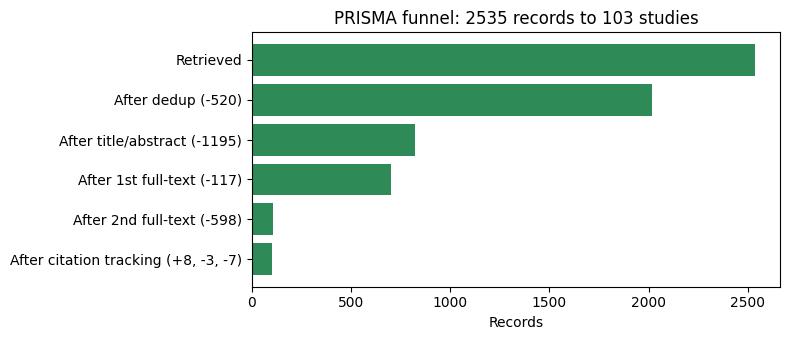

In [7]:
steps = [("Retrieved", 2535), ("After dedup (-520)", 2535-520),
         ("After title/abstract (-1195)", 2015-1195),
         ("After 1st full-text (-117)", 820-117),
         ("After 2nd full-text (-598)", 703-598),
         ("After citation tracking (+8, -3, -7)", 105+8-3-7)]
for name, n in steps: print(f"{name:40s} {n}")
assert steps[-1][1] == 103, "Should end at 103 included studies"

plt.figure(figsize=(8,3.5))
plt.barh([s[0] for s in steps][::-1], [s[1] for s in steps][::-1], color="seagreen")
plt.xlabel("Records"); plt.title("PRISMA funnel: 2535 records to 103 studies")
plt.tight_layout(); plt.show()

## 2. Reported coverage across the 103 studies

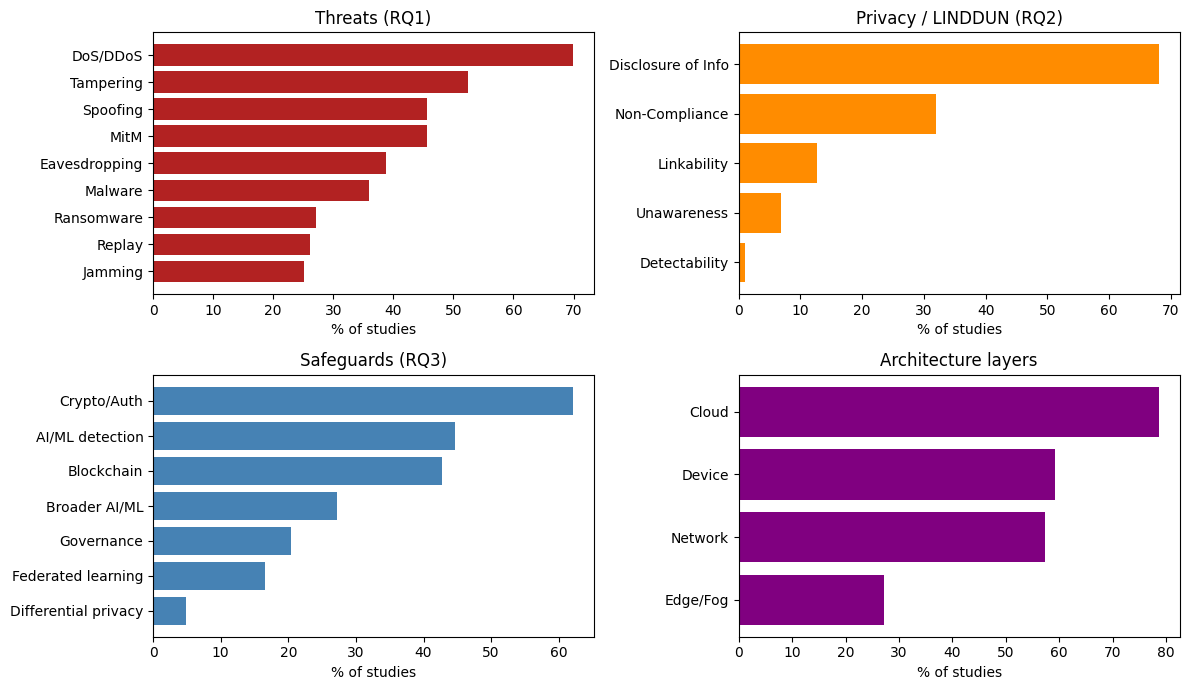

In [8]:
threats = {"DoS/DDoS":69.9,"Tampering":52.4,"Spoofing":45.6,"MitM":45.6,"Eavesdropping":38.8,
           "Malware":35.9,"Ransomware":27.2,"Replay":26.2,"Jamming":25.2}
privacy = {"Disclosure of Info":68.0,"Non-Compliance":32.0,"Linkability":12.6,"Unawareness":6.8,"Detectability":1.0}
solutions = {"Crypto/Auth":62.1,"AI/ML detection":44.7,"Blockchain":42.7,"Broader AI/ML":27.2,
             "Governance":20.4,"Federated learning":16.5,"Differential privacy":4.9}
layers = {"Cloud":78.6,"Device":59.2,"Network":57.3,"Edge/Fog":27.2}

fig, ax = plt.subplots(2, 2, figsize=(12,7))
for a,(t,d,c) in zip(ax.ravel(), [("Threats (RQ1)",threats,"firebrick"),("Privacy / LINDDUN (RQ2)",privacy,"darkorange"),
                                  ("Safeguards (RQ3)",solutions,"steelblue"),("Architecture layers",layers,"purple")]):
    a.barh(list(d)[::-1], list(d.values())[::-1], color=c); a.set_title(t); a.set_xlabel("% of studies")
plt.tight_layout(); plt.show()

## 3. Retrospective STRIDE coding + reliability

In [9]:
stride_dict = {
 "Spoofing": ["impersonat", "forged", "masquerad", "spoof"],
 "Tampering": ["falsif", "tamper", "modif", "inject"],
 "Repudiation": ["audit", "deny", "accountab"],
 "Information Disclosure": ["eavesdrop", "intercept", "leak", "expos"],
 "Denial of Service": ["ddos", "flood", "jamming", "denial-of-service"],
 "Elevation of Privilege": ["privilege escalation", "unauthorized control", "root access"],
}
snippets = {
 "Spoofing": "An attacker impersonates a legitimate soil sensor to the gateway.",
 "Tampering": "Falsified moisture readings trigger wrong irrigation decisions.",
 "Repudiation": "Weak audit logs make it hard to know who issued a command.",
 "Information Disclosure": "Eavesdropping on LoRaWAN traffic leaks farm yield data.",
 "Denial of Service": "A DDoS flood takes the irrigation controller offline.",
 "Elevation of Privilege": "Privilege escalation gives a compromised node control of actuators.",
}
cats = list(stride_dict)

true = np.zeros((20, len(cats)), int); texts = []
for i in range(20):
    pick = rng.choice(len(cats), size=rng.integers(1, 4), replace=False)
    true[i, pick] = 1
    texts.append(" ".join(snippets[cats[j]] for j in pick))

def code_text(t):
    t = t.lower()
    return [int(any(k in t for k in stride_dict[c])) for c in cats]

A = np.array([code_text(t) for t in texts])
flip = rng.random(A.shape) < 0.10
B = np.where(flip, 1 - A, A)

rows = []
for j, c in enumerate(cats):
    agree = (A[:, j] == B[:, j]).mean() * 100
    kappa = cohen_kappa_score(A[:, j], B[:, j]) if len(set(A[:, j])|set(B[:, j])) > 1 else np.nan
    rows.append((c, f"{agree:.0f}%", round(kappa, 3) if kappa == kappa else "not estimable"))
print(pd.DataFrame(rows, columns=["STRIDE category", "Observed agreement", "Cohen's kappa"]).to_string(index=False))

       STRIDE category Observed agreement  Cohen's kappa
              Spoofing                95%          0.894
             Tampering                90%          0.762
           Repudiation                85%          0.625
Information Disclosure                85%          0.483
     Denial of Service                90%          0.800
Elevation of Privilege                95%          0.900


## 4. Ecological validity rater

                                      study ecological_validity
Live-attack threat intel on real smart farm                High
   Federated IDS on generic network dataset                 Low
 Lightweight auth on lab Raspberry Pi nodes            Moderate
   Blockchain traceability, math proof only                 Low
LoRaWAN replay attack on irrigation testbed            Moderate
          CNN IDS, 98% on benchmark dataset                 Low
 Field trial of sensor auth, partial report            Moderate
          Drone spoofing test in open field                High


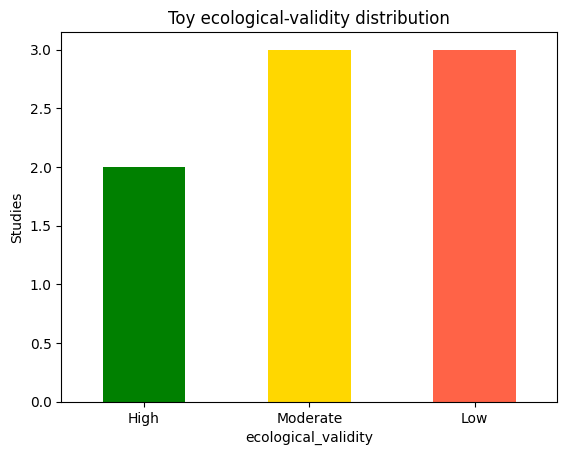

In [10]:
def eco_validity(env, ag_data, n_constraints, reported_under_conditions):
    if env == "field" and ag_data and n_constraints >= 2 and reported_under_conditions:
        return "High"
    if ag_data and env in ("lab", "testbed", "field"):
        return "Moderate"
    return "Low"

studies = pd.DataFrame([
 ("Live-attack threat intel on real smart farm", "field", True, 3, True),
 ("Federated IDS on generic network dataset",   "simulation", False, 0, False),
 ("Lightweight auth on lab Raspberry Pi nodes", "lab", True, 1, True),
 ("Blockchain traceability, math proof only",   "analytical", False, 0, False),
 ("LoRaWAN replay attack on irrigation testbed","testbed", True, 1, True),
 ("CNN IDS, 98% on benchmark dataset",          "simulation", False, 0, False),
 ("Field trial of sensor auth, partial report", "field", True, 2, False),
 ("Drone spoofing test in open field",          "field", True, 2, True),
], columns=["study", "env", "ag_data", "n_constraints", "reported"])

studies["ecological_validity"] = [eco_validity(r.env, r.ag_data, r.n_constraints, r.reported) for r in studies.itertuples()]
print(studies[["study", "ecological_validity"]].to_string(index=False))

counts = studies["ecological_validity"].value_counts().reindex(["High","Moderate","Low"]).fillna(0)
counts.plot(kind="bar", color=["green","gold","tomato"], rot=0, title="Toy ecological-validity distribution")
plt.ylabel("Studies"); plt.show()